# Module 4 — Rebalancing Simulator

Exploratory notebook for `analysis/rebalancing.py`. Given a target allocation
and the adjusted-close prices from Module 1, simulate and compare three
rebalancing strategies: never rebalance (`"none"`), rebalance every calendar
year (`"annual"`), and rebalance whenever any asset drifts too far from its
target weight (`"threshold"`).

**Key concepts:** conditional logic over time series, iterating over a
`DatetimeIndex`, stateful simulation loops.

> Convention (see `SPEC.md`): explore here first, then refactor the working
> logic into `analysis/rebalancing.py`. This notebook is kept as an honest
> artifact of the process.

## Setup

In [1]:
import sys
from pathlib import Path

# Make the project root importable when running from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from analysis import fetch, portfolio, rebalancing
from analysis.config import DEFAULT_TICKERS, DEFAULT_WEIGHTS, DEFAULT_START, DEFAULT_INVESTMENT

# Pull from the local cache written by Module 1 (network only on a miss).
prices = fetch.load_or_fetch(DEFAULT_TICKERS, DEFAULT_START)
prices.tail()

Ticker,VTI,VXUS,BND
Date,,,
2026-07-31,368.209991,84.589996,71.978004
2026-08-03,373.839996,85.019997,72.150002
2026-08-04,380.820007,86.449997,72.440002
2026-08-05,379.649994,86.510002,72.459999
2026-08-06,379.070007,86.320000,72.250000


## 1. Run all three strategies

`compare_strategies` runs `"none"`, `"annual"`, and `"threshold"` (default 5%
drift tolerance) over the same price history and lines their total portfolio
value up side by side.

In [2]:
comparison = rebalancing.compare_strategies(prices, DEFAULT_WEIGHTS, DEFAULT_INVESTMENT)
comparison.tail()

,none,annual,threshold
Date,,,
2026-07-31,46104.877075,41892.750645,42363.777707
2026-08-03,46712.746232,42353.798932,42836.670417
2026-08-04,47551.559625,43064.856894,43556.363927
2026-08-05,47440.178255,42994.542214,43482.639724
2026-08-06,47360.545967,42914.870520,43402.482126


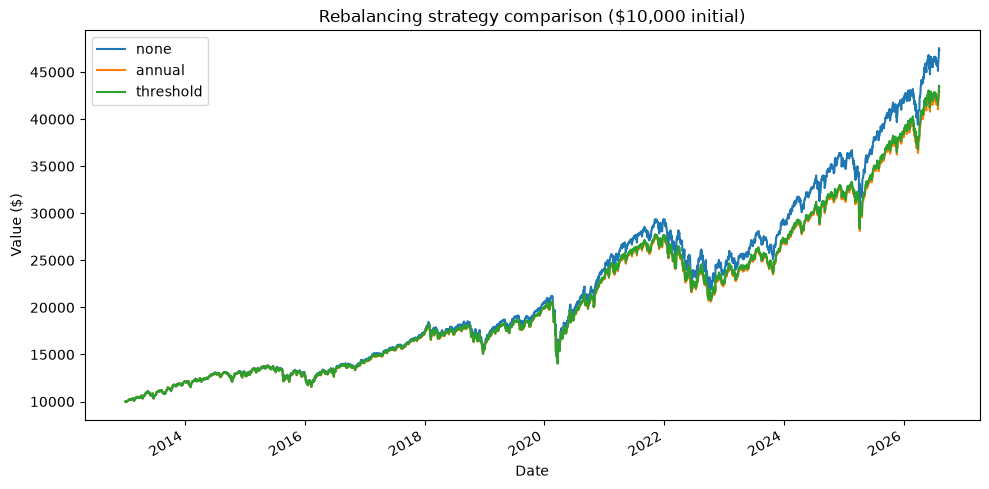

In [3]:
comparison.plot(figsize=(10, 5), title="Rebalancing strategy comparison ($10,000 initial)")
plt.ylabel("Value ($)")
plt.tight_layout()

## 2. Terminal value — how much does discipline actually matter?

Boglehead orthodoxy says rebalancing is about risk control, not return
enhancement — the terminal value gap between strategies is usually smaller
than people expect.

In [4]:
terminal = comparison.iloc[-1]
terminal.map(lambda x: f"${x:,.2f}")

none         $47,360.55
annual       $42,914.87
threshold    $43,402.48
Name: 2026-08-06 00:00:00, dtype: object

## 3. How often did each strategy actually trade?

Re-run `simulate` per strategy directly (rather than through
`compare_strategies`) to get each one's rebalance log.

In [5]:
logs = {}
for strategy in rebalancing.STRATEGIES:
    _, log = rebalancing.simulate(prices, DEFAULT_WEIGHTS, DEFAULT_INVESTMENT, strategy)
    logs[strategy] = log

event_counts = {s: log["date"].nunique() for s, log in logs.items()}
event_counts

{'none': 0, 'annual': 13, 'threshold': 6}

In [6]:
logs["threshold"].head(10)

,date,asset,action,amount
0,2014-03-20,VTI,sell,623.864391
1,2014-03-20,VXUS,buy,390.720927
2,2014-03-20,BND,buy,233.143464
3,2016-11-23,VTI,sell,695.813827
4,2016-11-23,VXUS,buy,624.450134
5,2016-11-23,BND,buy,71.363693
6,2020-07-31,VTI,sell,1021.507402
7,2020-07-31,VXUS,buy,732.236625
8,2020-07-31,BND,buy,289.270777
9,2022-03-28,VTI,sell,1308.613256


## 4. Max drawdown across strategies

Reuse `portfolio.max_drawdown` (Module 3) on each strategy's total value
series — rebalancing changes the mix over time, so the worst peak-to-trough
decline can differ even though terminal values are close.

In [7]:
drawdowns = {s: portfolio.max_drawdown(comparison[s]) for s in rebalancing.STRATEGIES}
for strategy, dd in drawdowns.items():
    print(f"{strategy:>10}: {dd:.2%}")

      none: -32.71%
    annual: -31.19%
 threshold: -31.93%


## Checkpoint

**What does `.resample('YE')` do and why is it useful for financial data?**

`.resample('YE')` groups a `DatetimeIndex`-based series or frame into
calendar-year-end buckets, the same way `.groupby()` groups by a column —
except the grouping key is a time period instead of a value. It's useful here
because "rebalance on the first trading day of each calendar year" is exactly
the kind of question resampling answers cleanly: instead of manually tracking
`current_date.year != prev_year` in a loop (the approach `simulate` takes for
clarity), you could resample the price index into yearly buckets and grab each
bucket's first date. The simulator's own loop reaches for the same idea in
its lower-level form, since it needs to interleave that check with the
day-by-day share/value updates a pure resample can't express on its own.